# 05 — Extract Backbone & Neck Features

**Goal:** Extract and visualize intermediate feature maps from the fine-tuned YOLO26s detector.

This notebook:
1. Loads the BDD100K-trained YOLO26s weights
2. Dynamically discovers all layers and registers forward hooks on every layer
3. Runs inference and captures feature maps
4. Prints a clear table of layer index, module class, output shape (C, H, W), and stride
5. Visualises selected feature maps and mean-activation heatmaps
6. Recommends which layers to use for the lane segmentation head

## 1 — Setup

In [1]:
!pip install -q ultralytics>=8.4.0 opencv-python matplotlib

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import sys
import random
import tarfile
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
from collections import OrderedDict

# ── Reproducibility ────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Paths ──────────────────────────────────────────────────────────
ECOCAR_ROOT = "/content/drive/MyDrive/EcoCAR"
WEIGHTS = os.path.join(ECOCAR_ROOT, "weights", "bdd100k_yolo26s_best.pt")
DATASET_DIR = "/content/bdd100k_yolo"
OUTPUT_DIR = os.path.join(ECOCAR_ROOT, "outputs", "05_features")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Input image size used by the model
IMG_SIZE = 640

# ── Extract dataset if not already present ─────────────────────────
TAR_PATH = os.path.join(ECOCAR_ROOT, "datasets", "bdd100k_yolo_nb02.tar")
if not os.path.isdir(os.path.join(DATASET_DIR, "images", "val")):
    if os.path.isfile(TAR_PATH):
        os.makedirs(DATASET_DIR, exist_ok=True)
        print(f"Extracting {TAR_PATH} ...")
        with tarfile.open(TAR_PATH, "r") as tar:
            tar.extractall(DATASET_DIR)
        print("Extraction complete.")
    else:
        print(f"WARNING: Tar not found: {TAR_PATH}")
        print("Run Notebook 02 first. Will use fallback test image.")
else:
    print(f"Dataset already exists: {DATASET_DIR}")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device:  {device}")
print(f"Weights: {WEIGHTS} (exists: {os.path.isfile(WEIGHTS)})")

Extracting /content/drive/MyDrive/EcoCAR/datasets/bdd100k_yolo_nb02.tar ...


/tmp/ipykernel_2465/3686481716.py:34: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATASET_DIR)


Extraction complete.
Device:  cuda
Weights: /content/drive/MyDrive/EcoCAR/weights/bdd100k_yolo26s_best.pt (exists: True)


## 2 — Load Model

In [4]:
from ultralytics import YOLO

model = YOLO(WEIGHTS)
inner_model = model.model  # The inner nn.Module

print(f"Model loaded: {len(model.names)} classes")
print(f"Task: {model.task}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Model loaded: 10 classes
Task: detect


## 3 — Dynamically Discover All Layers

In [5]:
# Dynamically discover the total number of top-level layers
num_layers = len(inner_model.model)
print(f"Total top-level layers: {num_layers}\n")

print(f"{'Idx':>4} {'Module':<35} {'Params':>10}")
print("-" * 55)
for idx in range(num_layers):
    layer = inner_model.model[idx]
    params = sum(p.numel() for p in layer.parameters())
    print(f"  {idx:>2}  {layer.__class__.__name__:<35} {params:>10,}")

Total top-level layers: 24

 Idx Module                                  Params
-------------------------------------------------------
   0  Conv                                       928
   1  Conv                                    18,560
   2  C3k2                                    26,080
   3  Conv                                   147,712
   4  C3k2                                   103,360
   5  Conv                                   590,336
   6  C3k2                                   346,112
   7  Conv                                 1,180,672
   8  C3k2                                 1,380,352
   9  SPPF                                   656,896
  10  C2PSA                                  990,976
  11  Upsample                                     0
  12  Concat                                       0
  13  C3k2                                   477,184
  14  Upsample                                     0
  15  Concat                                       0
  16  C3k2      

## 4 — Feature Extractor with Forward Hooks

In [6]:
class FeatureExtractor:
    """
    Register forward hooks on YOLO model layers to capture feature maps.

    Usage:
        extractor = FeatureExtractor(model.model)
        extractor.register_hooks(layer_indices=[2, 4, 6, 8])
        results = model("image.jpg")  # triggers hooks
        features = extractor.get_features()
        extractor.remove_hooks()
    """

    def __init__(self, model):
        self.model = model
        self._features = OrderedDict()
        self._hooks = []

    def _make_hook(self, name):
        def hook_fn(module, input, output):
            if isinstance(output, torch.Tensor):
                self._features[name] = output.detach()
            elif isinstance(output, (list, tuple)):
                for item in output:
                    if isinstance(item, torch.Tensor):
                        self._features[name] = item.detach()
                        break
        return hook_fn

    def register_hooks(self, layer_indices):
        self.remove_hooks()
        self._features.clear()

        n = len(self.model.model)
        registered = []
        for idx in layer_indices:
            if idx < 0 or idx >= n:
                print(f"  Warning: index {idx} out of range (0..{n-1})")
                continue
            layer = self.model.model[idx]
            name = f"layer_{idx}_{layer.__class__.__name__}"
            h = layer.register_forward_hook(self._make_hook(name))
            self._hooks.append(h)
            registered.append(name)

        print(f"Registered {len(registered)} hooks")
        return registered

    def get_features(self):
        return self._features

    def remove_hooks(self):
        for h in self._hooks:
            h.remove()
        self._hooks.clear()

    def clear_features(self):
        self._features.clear()

## 5 — Register Hooks on ALL Layers & Run Inference

In [7]:
# Hook every layer (except the final Detect head which outputs lists, not tensors)
detect_keywords = {'Detect', 'Segment', 'Classify', 'OBB', 'Pose', 'WorldDetect', 'E2EDetect'}
all_layer_indices = [
    idx for idx in range(num_layers)
    if inner_model.model[idx].__class__.__name__ not in detect_keywords
]

extractor = FeatureExtractor(inner_model)
extractor.register_hooks(all_layer_indices)

Registered 23 hooks


['layer_0_Conv',
 'layer_1_Conv',
 'layer_2_C3k2',
 'layer_3_Conv',
 'layer_4_C3k2',
 'layer_5_Conv',
 'layer_6_C3k2',
 'layer_7_Conv',
 'layer_8_C3k2',
 'layer_9_SPPF',
 'layer_10_C2PSA',
 'layer_11_Upsample',
 'layer_12_Concat',
 'layer_13_C3k2',
 'layer_14_Upsample',
 'layer_15_Concat',
 'layer_16_C3k2',
 'layer_17_Conv',
 'layer_18_Concat',
 'layer_19_C3k2',
 'layer_20_Conv',
 'layer_21_Concat',
 'layer_22_C3k2']

In [8]:
# Select a test image with fixed seed
val_images_dir = os.path.join(DATASET_DIR, "images", "val")

if os.path.isdir(val_images_dir):
    img_files = sorted([f for f in os.listdir(val_images_dir) if f.endswith(('.jpg', '.png'))])
    test_image = os.path.join(val_images_dir, random.choice(img_files))
else:
    import urllib.request
    test_image = "test_driving.jpg"
    if not os.path.exists(test_image):
        urllib.request.urlretrieve("https://ultralytics.com/images/bus.jpg", test_image)

print(f"Test image: {test_image} (seed={SEED})")

# Run inference — this triggers all hooks
results = model(test_image, imgsz=IMG_SIZE, verbose=False)
print(f"Inference complete. {len(results[0].boxes)} detections.")

Test image: /content/bdd100k_yolo/images/val/b63b1c14-f01a2f6b.jpg (seed=42)
Inference complete. 7 detections.


## 6 — Feature Shape Table (Index, Class, C x H x W, Stride)

In [9]:
features = extractor.get_features()

# Identify backbone vs neck boundary: first Concat or Upsample marks the neck
neck_start = num_layers  # default if not found
for idx in range(num_layers):
    cls = inner_model.model[idx].__class__.__name__
    if cls in ('Concat', 'Upsample'):
        neck_start = idx
        break

print(f"{'Idx':>4} {'Module':<25} {'C':>6} {'H':>5} {'W':>5} {'Stride':>7} {'Region':<10} {'MB':>7}")
print("-" * 75)

total_mb = 0
layer_info = []  # collect for later recommendations

for name, feat in features.items():
    idx = int(name.split('_')[1])
    cls_name = name.split('_', 2)[2]

    if feat.dim() >= 4:
        _, C, H, W = feat.shape
        stride = IMG_SIZE // H
        region = "backbone" if idx < neck_start else "neck"
    else:
        C, H, W = feat.shape[-1], '-', '-'
        stride = '-'
        region = "?"

    size_mb = feat.nelement() * feat.element_size() / (1024 ** 2)
    total_mb += size_mb

    print(
        f"  {idx:>2}  {cls_name:<25} {str(C):>6} {str(H):>5} {str(W):>5} "
        f"{str(stride):>7} {region:<10} {size_mb:>6.2f}"
    )
    layer_info.append(dict(idx=idx, cls=cls_name, C=C, H=H, W=W, stride=stride, region=region))

print(f"\nTotal feature memory: {total_mb:.2f} MB")
print(f"Layers captured: {len(features)}")

 Idx Module                         C     H     W  Stride Region          MB
---------------------------------------------------------------------------
   0  Conv                          32   192   320       3 backbone     7.50
   1  Conv                          64    96   160       6 backbone     3.75
   2  C3k2                         128    96   160       6 backbone     7.50
   3  Conv                         128    48    80      13 backbone     1.88
   4  C3k2                         256    48    80      13 backbone     3.75
   5  Conv                         256    24    40      26 backbone     0.94
   6  C3k2                         256    24    40      26 backbone     0.94
   7  Conv                         512    12    20      53 backbone     0.47
   8  C3k2                         512    12    20      53 backbone     0.47
   9  SPPF                         512    12    20      53 backbone     0.47
  10  C2PSA                        512    12    20      53 backbone     0.47


## 7 — Visualise Feature Maps

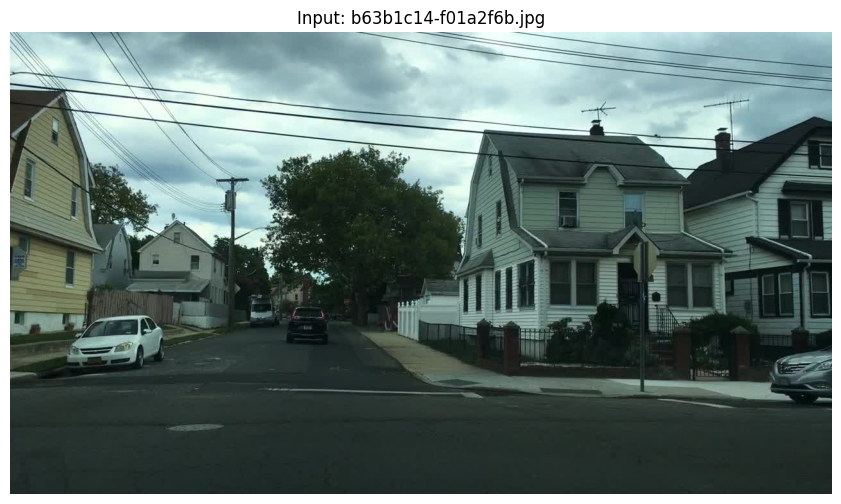

In [10]:
# Show the original image first
img = cv2.imread(test_image)
plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"Input: {os.path.basename(test_image)}")
plt.axis('off')
plt.show()

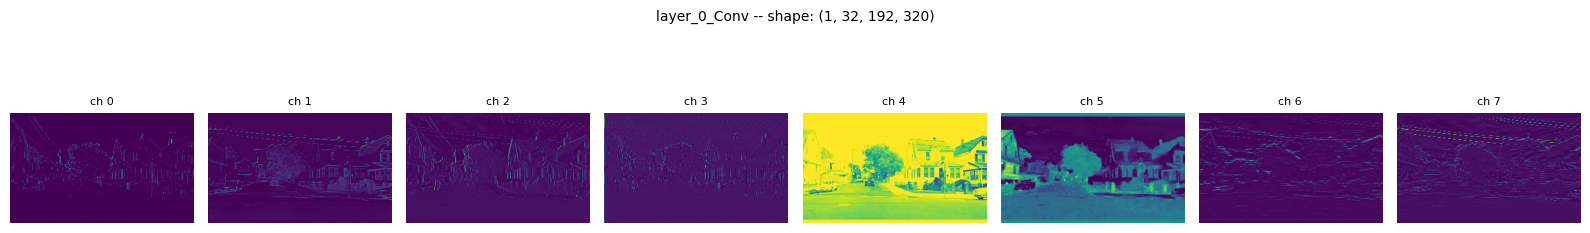

  Saved: /content/drive/MyDrive/EcoCAR/outputs/05_features/featuremap_layer_0_Conv.png


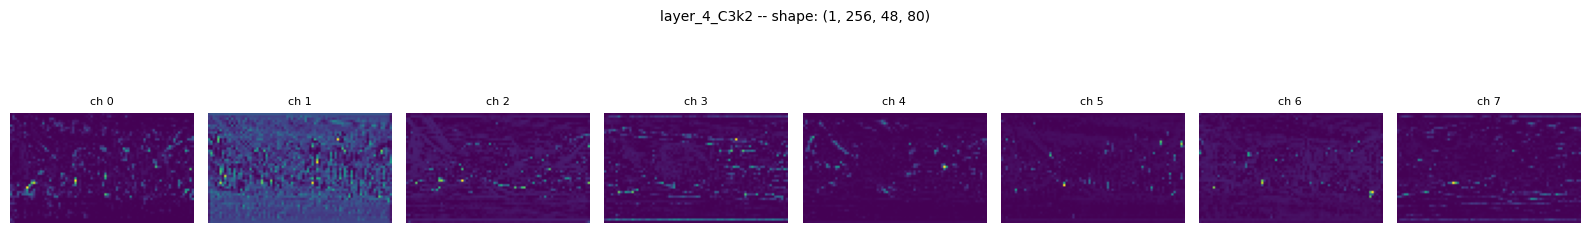

  Saved: /content/drive/MyDrive/EcoCAR/outputs/05_features/featuremap_layer_4_C3k2.png


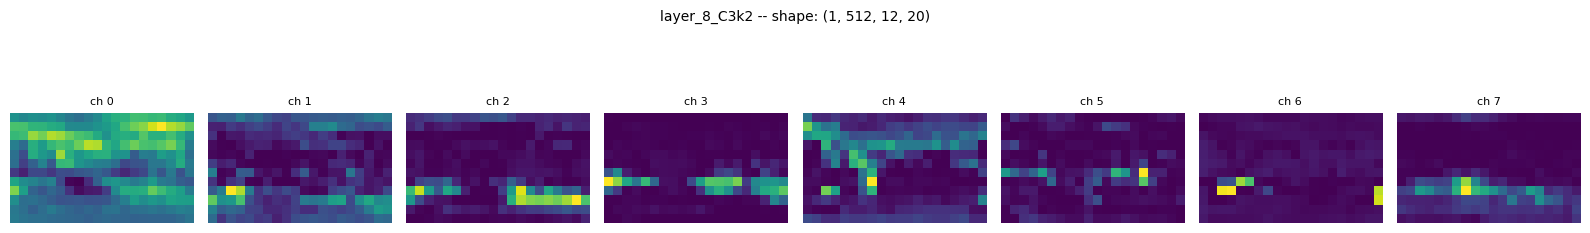

  Saved: /content/drive/MyDrive/EcoCAR/outputs/05_features/featuremap_layer_8_C3k2.png


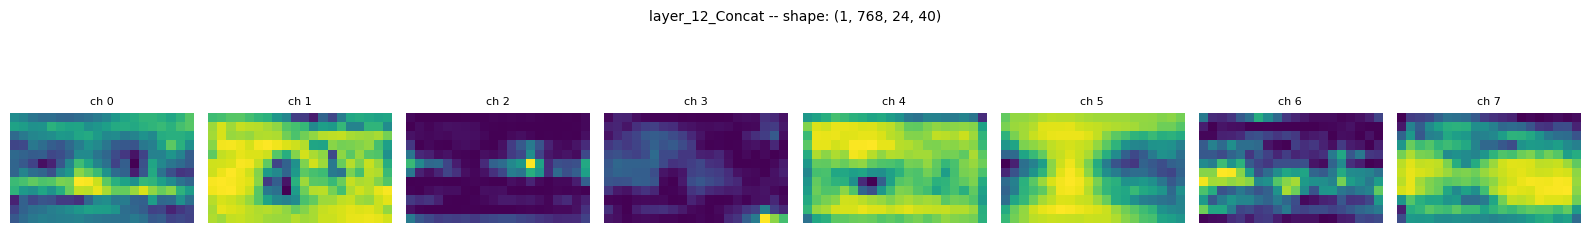

  Saved: /content/drive/MyDrive/EcoCAR/outputs/05_features/featuremap_layer_12_Concat.png


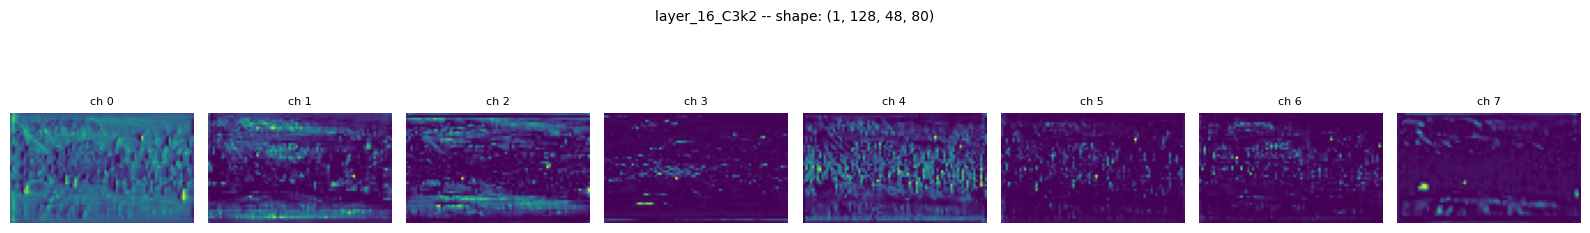

  Saved: /content/drive/MyDrive/EcoCAR/outputs/05_features/featuremap_layer_16_C3k2.png


In [11]:
# Visualise a spread of feature maps: early, mid backbone, and neck outputs
vis_keys = list(features.keys())
if len(vis_keys) > 5:
    step = max(1, len(vis_keys) // 5)
    vis_keys = [vis_keys[i] for i in range(0, len(vis_keys), step)][:5]

for layer_name in vis_keys:
    feat = features[layer_name]
    if feat.dim() < 4:
        print(f"  Skipping {layer_name} (shape {tuple(feat.shape)})")
        continue

    feat_2d = feat[0].cpu()  # (C, H, W)
    n_show = min(8, feat_2d.shape[0])

    fig, axes = plt.subplots(1, n_show, figsize=(16, 3))
    fig.suptitle(f"{layer_name} -- shape: {tuple(feat.shape)}", fontsize=10)

    for ch in range(n_show):
        axes[ch].imshow(feat_2d[ch].numpy(), cmap='viridis')
        axes[ch].set_title(f"ch {ch}", fontsize=8)
        axes[ch].axis('off')

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f"featuremap_{layer_name}.png")
    plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()
    print(f"  Saved: {save_path}")

## 8 — Mean Feature Activation Heatmaps

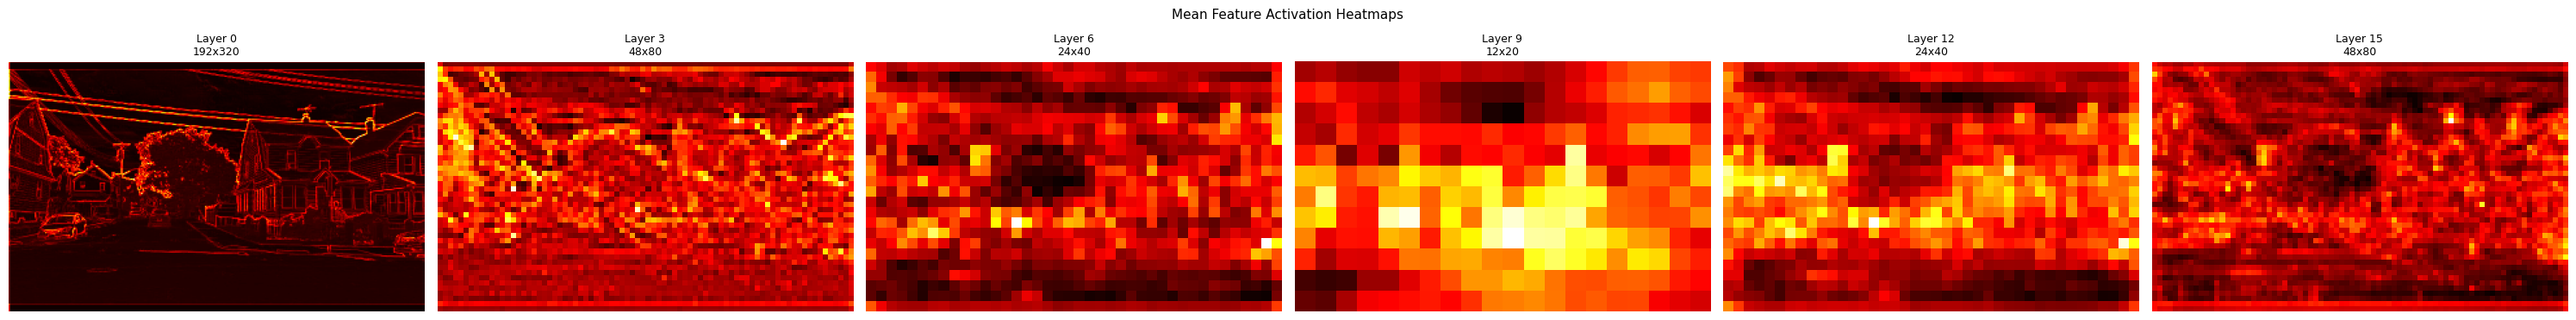

Saved: /content/drive/MyDrive/EcoCAR/outputs/05_features/mean_activation_heatmaps.png


In [12]:
# Mean-activation heatmaps
vis_hm = list(features.keys())
if len(vis_hm) > 6:
    step = max(1, len(vis_hm) // 6)
    vis_hm = [vis_hm[i] for i in range(0, len(vis_hm), step)][:6]

fig, axes = plt.subplots(1, len(vis_hm), figsize=(5 * len(vis_hm), 4))
if len(vis_hm) == 1:
    axes = [axes]

for i, layer_name in enumerate(vis_hm):
    feat = features[layer_name]
    if feat.dim() < 4:
        continue
    mean_act = feat[0].cpu().mean(dim=0).numpy()
    axes[i].imshow(mean_act, cmap='hot')
    idx = int(layer_name.split('_')[1])
    axes[i].set_title(f"Layer {idx}\n{feat.shape[2]}x{feat.shape[3]}", fontsize=9)
    axes[i].axis('off')

plt.suptitle('Mean Feature Activation Heatmaps', fontsize=11)
plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, "mean_activation_heatmaps.png")
plt.savefig(save_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")

## 9 — Recommendations for Lane Head

In [13]:
# ── Identify best early feature and neck outputs for lane head ─────

# Best early feature: highest-resolution backbone feature with spatial dims
# (i.e., the last backbone layer before the neck starts, at stride 8)
backbone_feats = [l for l in layer_info if l['region'] == 'backbone' and isinstance(l['H'], int)]
neck_feats     = [l for l in layer_info if l['region'] == 'neck'     and isinstance(l['H'], int)]

# Find stride-8, stride-16, stride-32 neck outputs (P3, P4, P5)
neck_by_stride = {}
for l in neck_feats:
    s = l['stride']
    if s in (8, 16, 32):
        neck_by_stride[s] = l  # last one at each stride wins (output of PAN)

# Best early lane feature: highest-resolution (lowest stride) backbone feature
best_early = None
if backbone_feats:
    best_early = min(backbone_feats, key=lambda l: l['stride'])

print("=" * 65)
print(" LANE HEAD FEATURE RECOMMENDATIONS")
print("=" * 65)

if best_early:
    print(f"\n  Best early feature (for fine spatial detail):")
    print(f"    Layer [{best_early['idx']}] {best_early['cls']}")
    print(f"    Shape: C={best_early['C']}, H={best_early['H']}, W={best_early['W']}, stride={best_early['stride']}")
    print(f"    --> suggested early_lane_idx = {best_early['idx']}")

print(f"\n  Neck output features (fused multi-scale):")
for s in sorted(neck_by_stride.keys()):
    l = neck_by_stride[s]
    label = {8: 'P3', 16: 'P4', 32: 'P5'}.get(s, f'P?')
    print(f"    {label}: Layer [{l['idx']}] {l['cls']}, C={l['C']}, stride={s}")

print(f"\n  Neck boundary starts at layer index: {neck_start}")

# Print config snippet
print("\n  -- MultiTaskYOLO config snippet --")
if best_early:
    print(f"    early_lane_idx:  {best_early['idx']}   # {best_early['cls']}, C={best_early['C']}, stride={best_early['stride']}")
neck_indices = [neck_by_stride[s]['idx'] for s in sorted(neck_by_stride.keys()) if s in neck_by_stride]
if neck_indices:
    print(f"    neck_out_indices: {neck_indices}  # P3/P4/P5")
print("=" * 65)

 LANE HEAD FEATURE RECOMMENDATIONS

  Best early feature (for fine spatial detail):
    Layer [0] Conv
    Shape: C=32, H=192, W=320, stride=3
    --> suggested early_lane_idx = 0

  Neck output features (fused multi-scale):

  Neck boundary starts at layer index: 11

  -- MultiTaskYOLO config snippet --
    early_lane_idx:  0   # Conv, C=32, stride=3


## 10 — Cleanup & Summary

In [14]:
extractor.remove_hooks()

print("\n" + "=" * 60)
print(" FEATURE EXTRACTION SUMMARY")
print("=" * 60)
print(f" Model:             {WEIGHTS}")
print(f" Total layers:      {num_layers}")
print(f" Layers hooked:     {len(features)}")
print(f" Backbone layers:   0..{neck_start - 1}")
print(f" Neck layers:       {neck_start}..{num_layers - 2}")
print(f" Total memory:      {total_mb:.2f} MB")
print(f" Outputs saved to:  {OUTPUT_DIR}")
if best_early:
    print(f" Suggested early_lane_idx: {best_early['idx']}")
print("=" * 60)
print("\nNext: notebook 06 for detailed model inspection")


 FEATURE EXTRACTION SUMMARY
 Model:             /content/drive/MyDrive/EcoCAR/weights/bdd100k_yolo26s_best.pt
 Total layers:      24
 Layers hooked:     23
 Backbone layers:   0..10
 Neck layers:       11..22
 Total memory:      51.09 MB
 Outputs saved to:  /content/drive/MyDrive/EcoCAR/outputs/05_features
 Suggested early_lane_idx: 0

Next: notebook 06 for detailed model inspection
